###  Implemention of  Hyperparameter Tuning using GridSearchCV / RandomizedSearchCV, we will be using fake news dataset for this project

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import re
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# NLP libraries and tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#remove warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# load the dataset
df = pd.read_csv('news_dataset.csv')

In [3]:
#checking the dataset
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [4]:
#checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


In [5]:
# checking the shape of the dataset
df.shape

(9900, 2)

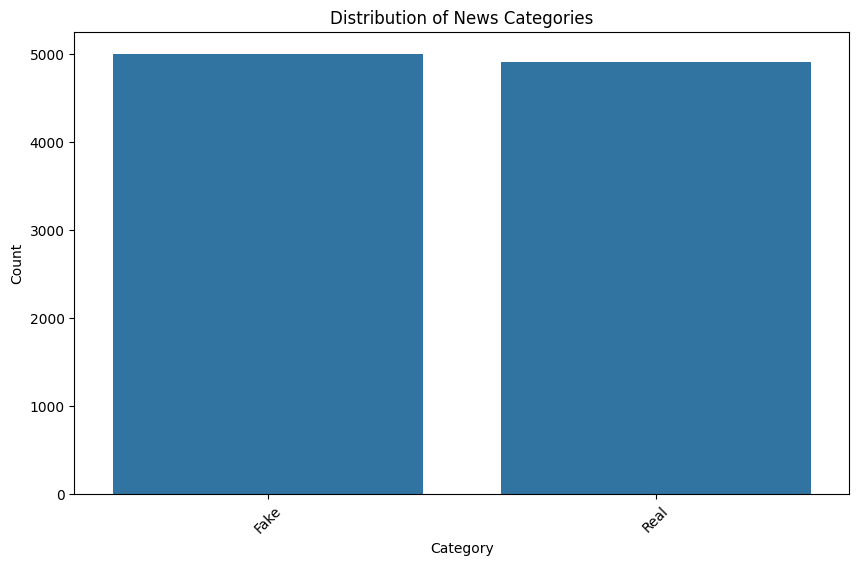

In [6]:
# visualize the distribution of categories
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df)
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [7]:
# checking missing values in the dataset
df.isnull().sum()


Text     0
label    0
dtype: int64

In [8]:
# checking the duplicates values in the dataset
df.duplicated().sum()

35

In [9]:
# print duplicates vlaues in the dataset
df[df.duplicated()]

,Text,label
1576,Highlights: The Trump presidency on April 13 a...,Real
2173,Trump asks Supreme Court to block travel ban r...,Real
2887,Trump tries to rally support for healthcare bi...,Real
3330,Highlights: The Trump presidency on March 31 a...,Real
3401,Highlights: The Trump presidency on April 26 a...,Real
3432,Former Trump security aide was Russia blackmai...,Real
3861,Highlights: The Trump presidency on April 13 a...,Real
4123,Highlights: The Trump presidency on March 31 a...,Real
4525,'Nuclear option' fallout? More extreme U.S. ju...,Real
4727,Highlights: The Trump presidency on April 21 a...,Real


In [10]:
# remove the duplicates values in the dataset
df.drop_duplicates(inplace=True)

In [11]:
# again checking the duplicates values in the dataset
df.duplicated().sum()

0

#### preprocessing and model training

In [12]:
# preprocess the text data using advance text cleaning techniques to improve the performance of the models
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Advanced NLP preprocessing pipeline:
    - Lowercasing
    - Remove URLs and HTML tags
    - Normalize currency and numbers
    - Remove special characters
    - Tokenization (NLTK)
    - POS tagging
    - Lemmatization with POS
    - Stopword removal
    - Remove short tokens
    - Clean extra spaces
    """
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 4. Normalize currency (e.g., $100.50 → money)
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    
    # 5. Normalize numbers (e.g., 123 → number)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)
    
    # 6. Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Tokenization using NLTK
    tokens = word_tokenize(text)
    
    # 8. POS tagging
    pos_tags = pos_tag(tokens)
    
    # 9. Helper function for POS conversion (inside function as requested)
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('N'):
            return 'n'  # noun
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'
    
    # 10. Lemmatization + stopword removal + short word filtering
    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            cleaned_words.append(lemma)
    
    # 11. Join tokens
    text = ' '.join(cleaned_words)
    
    # 12. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [13]:
# applying function to the dataset
df['Text'] = df['Text'].apply(preprocess_text)

In [14]:
df.head()

,Text,label
0,top trump surrogate brutally stab back patheti...,Fake
1,conservative leader optimistic common ground h...,Real
2,trump propose tax overhaul stir concern defici...,Real
3,court force ohio allow million illegally purge...,Fake
4,democrat say trump agrees work immigration bil...,Real


In [15]:
# converting data into target and features
X = df['Text']
y = df['label']

In [16]:
# we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [17]:
# Save label encoder for future use
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [18]:
# train test split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [19]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [20]:
# ================= BASELINE MODEL =================
baseline_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

baseline_pipe.fit(X_train, y_train)
baseline_preds = baseline_pipe.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_preds)

print("\n===== BASELINE LOGISTIC REGRESSION =====")
print("Accuracy:", baseline_acc)
print(classification_report(y_test, baseline_preds))


===== BASELINE LOGISTIC REGRESSION =====
Accuracy: 0.99341104916371
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99       973

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973



In [21]:
# ================= GRID SEARCH =================
grid_params = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs'],
    'clf__penalty': ['l2']   # safe for both solvers
}

grid = GridSearchCV(pipeline, grid_params, cv=3, n_jobs=-1)

start = time.time()
grid.fit(X_train, y_train)
grid_time = time.time() - start

grid_preds = grid.predict(X_test)
grid_acc = accuracy_score(y_test, grid_preds)

print("\n===== GRID SEARCH =====")
print("Best Params:", grid.best_params_)
print("Accuracy:", grid_acc)
print("Time:", grid_time)


===== GRID SEARCH =====
Best Params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.9969589457678661
Time: 80.46682548522949


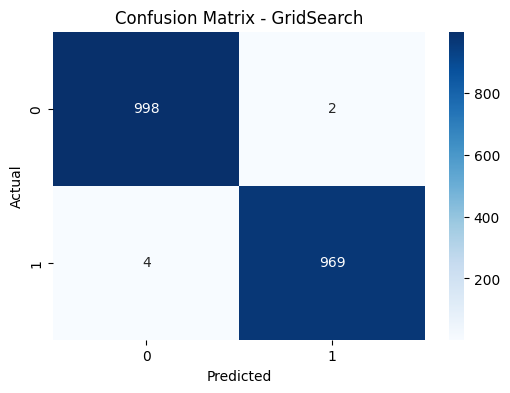

In [22]:
# Confusion Matrix - Grid Search
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, grid_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - GridSearch")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# ================= RANDOM SEARCH =================
random_params = {
    'tfidf__max_features': [2000, 3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': np.linspace(0.01, 10, 30),
    'clf__solver': ['liblinear', 'lbfgs'],
    'clf__penalty': ['l2']
}

random = RandomizedSearchCV(
    pipeline,
    random_params,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1
)

start = time.time()
random.fit(X_train, y_train)
random_time = time.time() - start

random_preds = random.predict(X_test)
random_acc = accuracy_score(y_test, random_preds)

print("\n===== RANDOM SEARCH =====")
print("Best Params:", random.best_params_)
print("Accuracy:", random_acc)
print("Time:", random_time)



===== RANDOM SEARCH =====
Best Params: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 3000, 'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 7.933103448275862}
Accuracy: 0.9969589457678661
Time: 28.601612091064453


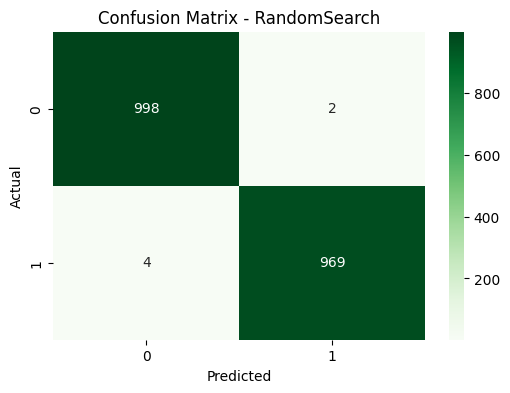

In [24]:
# Confusion Matrix - Random Search
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, random_preds), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - RandomSearch")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# ================= COMPARISON TABLE =================

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "GridSearch", "RandomSearch"],
    "Accuracy": [baseline_acc, grid_acc, random_acc]
})

print("\n===== MODEL COMPARISON =====")
print(comparison_df)


===== MODEL COMPARISON =====
          Model  Accuracy
0      Baseline  0.993411
1    GridSearch  0.996959
2  RandomSearch  0.996959


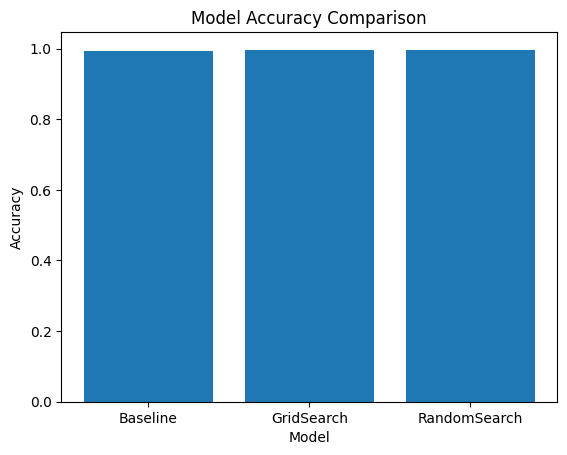

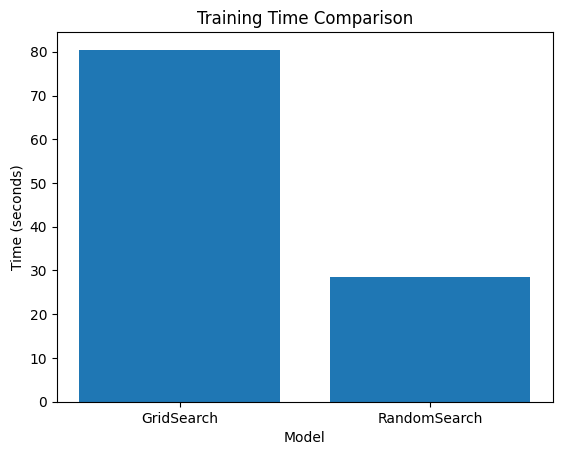

In [26]:
# ================= VISUALIZATION =================

# Accuracy Plot
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

# Time Comparison Plot
time_df = pd.DataFrame({
    "Model": ["GridSearch", "RandomSearch"],
    "Time": [grid_time, random_time]
})

plt.figure()
plt.bar(time_df["Model"], time_df["Time"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()

In [27]:
# save the best model for future use
if grid_acc >= random_acc:
    best_model = grid.best_estimator_
else:
    best_model = random.best_estimator_
pickle.dump(best_model, open("best_model.pkl", "wb"))

print("\nModel saved successfully!")


Model saved successfully!


In [30]:
# ================= PREDICTION SYSTEM =================

print("\n===== FINAL OUTPUT =====")

# Show best results
if grid_acc >= random_acc:
    best_params = grid.best_params_
    best_acc = grid_acc
else:
    best_params = random.best_params_
    best_acc = random_acc

print(f"Best Parameters: {best_params}")
print(f"Best Accuracy: {best_acc:.4f}")

print(f"\nBefore Tuning Accuracy: {baseline_acc:.4f}")
print(f"After Tuning Accuracy: {best_acc:.4f}")

# Take single input
text = input("\nEnter text: ")

# Preprocess
processed_text = preprocess_text(text)

# Predict
prediction = best_model.predict([processed_text])
label = label_encoder.inverse_transform(prediction)

print(f"\nPrediction (Tuned Model): {label[0]}")


===== FINAL OUTPUT =====
Best Parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Best Accuracy: 0.9970

Before Tuning Accuracy: 0.9934
After Tuning Accuracy: 0.9970

Prediction (Tuned Model): Real
